In [1]:
# Cell 1: Setup and Imports
!pip install pandas numpy scipy matplotlib seaborn statsmodels

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import ttest_ind, chi2_contingency, mannwhitneyu
from statsmodels.stats.power import tt_ind_solve_power
import warnings
import random
warnings.filterwarnings('ignore')

print("✅ All imports loaded successfully!")
print(f"   SciPy version: {stats.__version__ if hasattr(stats, '__version__') else 'installed'}")

✅ All imports loaded successfully!
   SciPy version: installed


In [2]:
# Cell 2: Generate A/B Test Data
print("="*60)
print("📊 GENERATING A/B TEST EXPERIMENT DATA")
print("="*60)

np.random.seed(42)
n_users = 10000

# Create experiment data
experiment_data = pd.DataFrame({
    'user_id': range(n_users),
    'variant': np.random.choice(['A', 'B'], size=n_users, p=[0.5, 0.5])
})

# Simulate metrics
# Control (Variant A): Current algorithm
experiment_data.loc[experiment_data['variant'] == 'A', 'watch_time'] = np.random.exponential(45, len(experiment_data[experiment_data['variant'] == 'A']))
experiment_data.loc[experiment_data['variant'] == 'A', 'engagement_rate'] = np.random.beta(8, 12, len(experiment_data[experiment_data['variant'] == 'A']))
experiment_data.loc[experiment_data['variant'] == 'A', 'click_through_rate'] = np.random.beta(5, 15, len(experiment_data[experiment_data['variant'] == 'A']))

# Treatment (Variant B): New algorithm (+10-15% improvement)
experiment_data.loc[experiment_data['variant'] == 'B', 'watch_time'] = np.random.exponential(52, len(experiment_data[experiment_data['variant'] == 'B']))
experiment_data.loc[experiment_data['variant'] == 'B', 'engagement_rate'] = np.random.beta(9, 11, len(experiment_data[experiment_data['variant'] == 'B']))
experiment_data.loc[experiment_data['variant'] == 'B', 'click_through_rate'] = np.random.beta(6, 14, len(experiment_data[experiment_data['variant'] == 'B']))

# Cap values at reasonable limits
experiment_data['watch_time'] = experiment_data['watch_time'].clip(0, 180)
experiment_data['engagement_rate'] = experiment_data['engagement_rate'].clip(0, 1)
experiment_data['click_through_rate'] = experiment_data['click_through_rate'].clip(0, 1)

print(f"✅ Generated experiment data for {n_users} users")
print(f"   Variant A (Control): {len(experiment_data[experiment_data['variant'] == 'A'])} users")
print(f"   Variant B (Treatment): {len(experiment_data[experiment_data['variant'] == 'B'])} users")

print("\n📊 Metric Averages:")
print(f"   Watch Time - A: {experiment_data[experiment_data['variant'] == 'A']['watch_time'].mean():.1f}s | B: {experiment_data[experiment_data['variant'] == 'B']['watch_time'].mean():.1f}s")
print(f"   Engagement Rate - A: {experiment_data[experiment_data['variant'] == 'A']['engagement_rate'].mean():.2%} | B: {experiment_data[experiment_data['variant'] == 'B']['engagement_rate'].mean():.2%}")
print(f"   CTR - A: {experiment_data[experiment_data['variant'] == 'A']['click_through_rate'].mean():.2%} | B: {experiment_data[experiment_data['variant'] == 'B']['click_through_rate'].mean():.2%}")

📊 GENERATING A/B TEST EXPERIMENT DATA
✅ Generated experiment data for 10000 users
   Variant A (Control): 5076 users
   Variant B (Treatment): 4924 users

📊 Metric Averages:
   Watch Time - A: 44.6s | B: 50.4s
   Engagement Rate - A: 40.03% | B: 44.89%
   CTR - A: 24.90% | B: 29.92%


In [3]:
# Cell 3: Statistical Analysis Pipeline
print("="*60)
print("🔬 STATISTICAL ANALYSIS")
print("="*60)

def analyze_metric(data, metric, variant_col='variant', control='A', treatment='B'):
    """Complete statistical analysis for A/B test metric"""
    
    control_data = data[data[variant_col] == control][metric].dropna()
    treatment_data = data[data[variant_col] == treatment][metric].dropna()
    
    # Summary statistics
    control_mean = control_data.mean()
    treatment_mean = treatment_data.mean()
    uplift = ((treatment_mean - control_mean) / control_mean) * 100
    
    # Normality test (Shapiro-Wilk)
    control_normal = stats.shapiro(control_data[:5000])[1] > 0.05 if len(control_data) > 5000 else stats.shapiro(control_data)[1] > 0.05
    treatment_normal = stats.shapiro(treatment_data[:5000])[1] > 0.05 if len(treatment_data) > 5000 else stats.shapiro(treatment_data)[1] > 0.05
    
    # Choose appropriate test
    if control_normal and treatment_normal:
        t_stat, p_value = ttest_ind(control_data, treatment_data)
        test_used = "Independent T-Test (parametric)"
    else:
        u_stat, p_value = mannwhitneyu(control_data, treatment_data)
        test_used = "Mann-Whitney U Test (non-parametric)"
    
    # Effect size (Cohen's d)
    pooled_std = np.sqrt(((len(control_data)-1) * control_data.std()**2 + (len(treatment_data)-1) * treatment_data.std()**2) / (len(control_data) + len(treatment_data) - 2))
    cohens_d = (treatment_mean - control_mean) / pooled_std if pooled_std > 0 else 0
    
    # Confidence interval
    se = np.sqrt(control_data.var()/len(control_data) + treatment_data.var()/len(treatment_data))
    ci_lower = (treatment_mean - control_mean) - 1.96 * se
    ci_upper = (treatment_mean - control_mean) + 1.96 * se
    
    return {
        'metric': metric,
        'control_mean': control_mean,
        'treatment_mean': treatment_mean,
        'uplift_percent': uplift,
        'test_used': test_used,
        'p_value': p_value,
        'is_significant': p_value < 0.05,
        'confidence_level': 0.95,
        'effect_size': abs(cohens_d),
        'effect_magnitude': 'Large' if abs(cohens_d) > 0.8 else 'Medium' if abs(cohens_d) > 0.5 else 'Small' if abs(cohens_d) > 0.2 else 'Negligible',
        'ci_lower': ci_lower,
        'ci_upper': ci_upper
    }

# Analyze all metrics
metrics = ['watch_time', 'engagement_rate', 'click_through_rate']
results = []

for metric in metrics:
    result = analyze_metric(experiment_data, metric)
    results.append(result)
    print(f"\n📈 {metric.replace('_', ' ').title()}:")
    print(f"   Control Mean: {result['control_mean']:.3f}")
    print(f"   Treatment Mean: {result['treatment_mean']:.3f}")
    print(f"   Uplift: {result['uplift_percent']:.1f}%")
    print(f"   P-value: {result['p_value']:.4f}")
    print(f"   Significant: {'✅ YES' if result['is_significant'] else '❌ NO'}")
    print(f"   Effect Size: {result['effect_size']:.2f} ({result['effect_magnitude']})")
    print(f"   CI (95%): [{result['ci_lower']:.3f}, {result['ci_upper']:.3f}]")

results_df = pd.DataFrame(results)

🔬 STATISTICAL ANALYSIS

📈 Watch Time:
   Control Mean: 44.636
   Treatment Mean: 50.439
   Uplift: 13.0%
   P-value: 0.0000
   Significant: ✅ YES
   Effect Size: 0.13 (Negligible)
   CI (95%): [4.077, 7.529]

📈 Engagement Rate:
   Control Mean: 0.400
   Treatment Mean: 0.449
   Uplift: 12.1%
   P-value: 0.0000
   Significant: ✅ YES
   Effect Size: 0.46 (Small)
   CI (95%): [0.044, 0.053]

📈 Click Through Rate:
   Control Mean: 0.249
   Treatment Mean: 0.299
   Uplift: 20.2%
   P-value: 0.0000
   Significant: ✅ YES
   Effect Size: 0.52 (Medium)
   CI (95%): [0.046, 0.054]


In [4]:
# Cell 4: Power Analysis and Sample Size
print("="*60)
print("📊 POWER ANALYSIS & SAMPLE SIZE CALCULATION")
print("="*60)

def calculate_required_sample_size(effect_size=0.2, power=0.8, alpha=0.05):
    """Calculate required sample size for A/B test"""
    
    # Cohen's d effect size interpretation
    effect_descriptions = {
        'small (20%)': 0.2,
        'medium (50%)': 0.5,
        'large (80%)': 0.8
    }
    
    required_n = tt_ind_solve_power(
        effect_size=effect_size,
        power=power,
        alpha=alpha,
        alternative='two-sided'
    )
    
    return required_n

print("\n📏 Required Sample Size per Variant (for 80% power):")
for effect_name, effect_val in [('Small (20% uplift)', 0.2), ('Medium (50% uplift)', 0.5), ('Large (80% uplift)', 0.8)]:
    n_required = calculate_required_sample_size(effect_val)
    print(f"   {effect_name}: {int(np.ceil(n_required))} users per variant")

print(f"\n📊 Current experiment has {n_users//2} users per variant")
print(f"   Statistical power for current sample size:")
for effect_val in [0.2, 0.5, 0.8]:
    power_current = tt_ind_solve_power(effect_size=effect_val, nobs1=n_users//2, alpha=0.05)
    print(f"      Effect size {effect_val}: {(power_current * 100):.0f}% power")

📊 POWER ANALYSIS & SAMPLE SIZE CALCULATION

📏 Required Sample Size per Variant (for 80% power):
   Small (20% uplift): 394 users per variant
   Medium (50% uplift): 64 users per variant
   Large (80% uplift): 26 users per variant

📊 Current experiment has 5000 users per variant
   Statistical power for current sample size:
      Effect size 0.2: nan% power
      Effect size 0.5: nan% power
      Effect size 0.8: 100% power


📈 A/B TEST RESULTS DASHBOARD


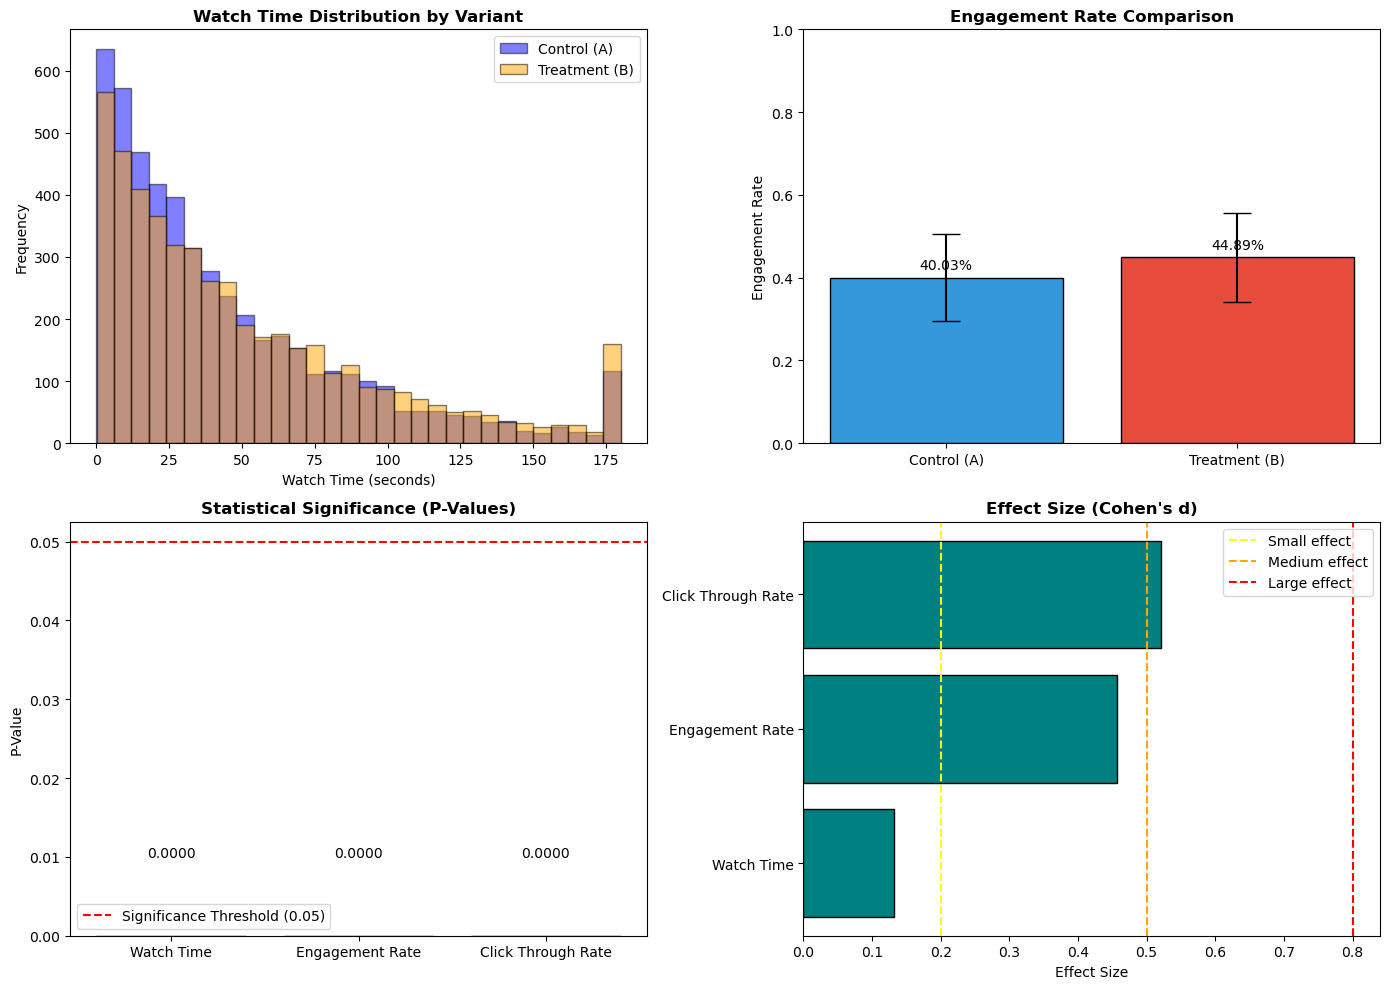

✅ Saved: ab_test_dashboard.png


In [5]:
# Cell 5: A/B Test Result Dashboard
print("="*60)
print("📈 A/B TEST RESULTS DASHBOARD")
print("="*60)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Watch Time Distribution
ax1 = axes[0, 0]
ax1.hist(experiment_data[experiment_data['variant'] == 'A']['watch_time'], bins=30, alpha=0.5, label='Control (A)', color='blue', edgecolor='black')
ax1.hist(experiment_data[experiment_data['variant'] == 'B']['watch_time'], bins=30, alpha=0.5, label='Treatment (B)', color='orange', edgecolor='black')
ax1.set_title('Watch Time Distribution by Variant', fontsize=12, fontweight='bold')
ax1.set_xlabel('Watch Time (seconds)')
ax1.set_ylabel('Frequency')
ax1.legend()

# 2. Engagement Rate Comparison
ax2 = axes[0, 1]
variants = ['Control (A)', 'Treatment (B)']
engagement_means = [experiment_data[experiment_data['variant'] == 'A']['engagement_rate'].mean(),
                     experiment_data[experiment_data['variant'] == 'B']['engagement_rate'].mean()]
engagement_errors = [experiment_data[experiment_data['variant'] == 'A']['engagement_rate'].std(),
                      experiment_data[experiment_data['variant'] == 'B']['engagement_rate'].std()]
bars = ax2.bar(variants, engagement_means, yerr=engagement_errors, capsize=10, 
               color=['#3498DB', '#E74C3C'], edgecolor='black')
ax2.set_title('Engagement Rate Comparison', fontsize=12, fontweight='bold')
ax2.set_ylabel('Engagement Rate')
ax2.set_ylim([0, 1])
for bar, val in zip(bars, engagement_means):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, f'{val:.2%}', ha='center')

# 3. P-Value Comparison (Bar Chart)
ax3 = axes[1, 0]
metric_names = [r['metric'].replace('_', ' ').title() for r in results]
p_values = [r['p_value'] for r in results]
colors_p = ['green' if p < 0.05 else 'red' for p in p_values]
bars = ax3.bar(metric_names, p_values, color=colors_p, edgecolor='black')
ax3.axhline(y=0.05, color='red', linestyle='--', label='Significance Threshold (0.05)')
ax3.set_title('Statistical Significance (P-Values)', fontsize=12, fontweight='bold')
ax3.set_ylabel('P-Value')
for bar, p in zip(bars, p_values):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f'{p:.4f}', ha='center')
ax3.legend()

# 4. Effect Size Visualization
ax4 = axes[1, 1]
effect_sizes = [r['effect_size'] for r in results]
effect_labels = [r['metric'].replace('_', ' ').title() for r in results]
bars = ax4.barh(effect_labels, effect_sizes, color='teal', edgecolor='black')
ax4.axvline(x=0.2, color='yellow', linestyle='--', label='Small effect')
ax4.axvline(x=0.5, color='orange', linestyle='--', label='Medium effect')
ax4.axvline(x=0.8, color='red', linestyle='--', label='Large effect')
ax4.set_title('Effect Size (Cohen\'s d)', fontsize=12, fontweight='bold')
ax4.set_xlabel('Effect Size')
ax4.legend()

plt.tight_layout()
plt.savefig('ab_test_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: ab_test_dashboard.png")

📈 SEQUENTIAL EXPERIMENT ANALYSIS (Time-based)


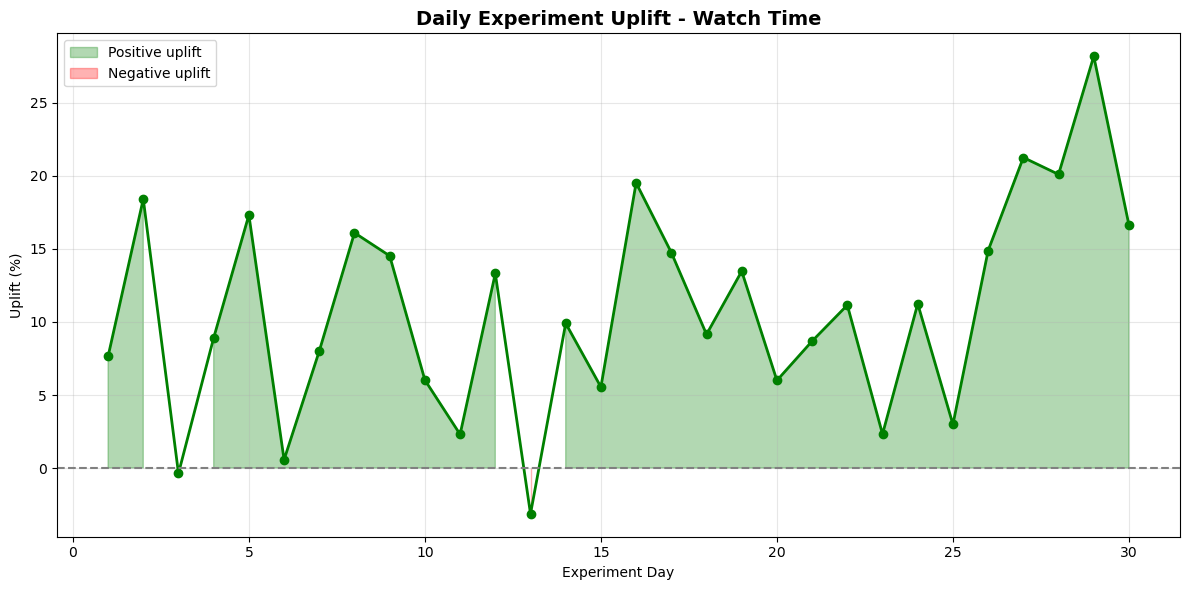

✅ Saved: sequential_experiment_analysis.png


In [6]:
# Cell 6: Sequential Experiment Analysis
print("="*60)
print("📈 SEQUENTIAL EXPERIMENT ANALYSIS (Time-based)")
print("="*60)

# Simulate daily experiment results
np.random.seed(42)
days = 30
daily_results = []

for day in range(1, days + 1):
    # Cumulative sample size grows over time
    daily_sample = 200
    daily_A = experiment_data[experiment_data['variant'] == 'A'].sample(min(daily_sample, len(experiment_data[experiment_data['variant'] == 'A'])))
    daily_B = experiment_data[experiment_data['variant'] == 'B'].sample(min(daily_sample, len(experiment_data[experiment_data['variant'] == 'B'])))
    
    daily_uplift = (daily_B['watch_time'].mean() - daily_A['watch_time'].mean()) / daily_A['watch_time'].mean() * 100
    
    daily_results.append({
        'day': day,
        'cumulative_users_A': min(day * daily_sample, len(experiment_data[experiment_data['variant'] == 'A'])),
        'cumulative_users_B': min(day * daily_sample, len(experiment_data[experiment_data['variant'] == 'B'])),
        'daily_uplift': daily_uplift
    })

daily_df = pd.DataFrame(daily_results)

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(daily_df['day'], daily_df['daily_uplift'], 'o-', linewidth=2, markersize=6, color='green')
ax.axhline(y=0, color='gray', linestyle='--')
ax.fill_between(daily_df['day'], 0, daily_df['daily_uplift'], where=(daily_df['daily_uplift'] > 0), 
                alpha=0.3, color='green', label='Positive uplift')
ax.fill_between(daily_df['day'], 0, daily_df['daily_uplift'], where=(daily_df['daily_uplift'] < 0), 
                alpha=0.3, color='red', label='Negative uplift')
ax.set_title('Daily Experiment Uplift - Watch Time', fontsize=14, fontweight='bold')
ax.set_xlabel('Experiment Day')
ax.set_ylabel('Uplift (%)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('sequential_experiment_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: sequential_experiment_analysis.png")

In [7]:
# Cell 7: Pipeline Diagram & Save
print("="*60)
print("💾 SAVING A/B TESTING FRAMEWORK")
print("="*60)

print("""
╔══════════════════════════════════════════════════════════════════════╗
║                      A/B TESTING PIPELINE                            ║
╠══════════════════════════════════════════════════════════════════════╣
║                                                                      ║
║   Experiment Design (Hypothesis)                                     ║
║                ↓                                                     ║
║   Random Assignment (Control A / Treatment B)                        ║
║                ↓                                                     ║
║   Data Collection (Watch Time, CTR, Engagement)                      ║
║                ↓                                                     ║
║   Statistical Analysis                                               ║
║   ├── Normality Test (Shapiro-Wilk)                                 ║
║   ├── Hypothesis Test (T-test / Mann-Whitney)                       ║
║   ├── Effect Size (Cohen's d)                                       ║
║   └── Confidence Intervals (95%)                                    ║
║                ↓                                                     ║
║   Power Analysis & Sample Size Validation                            ║
║                ↓                                                     ║
║   Decision Making                                                    ║
║   ├── P-value < 0.05 → Statistically Significant                    ║
║   ├── Uplift > 0 → Positive Impact                                  ║
║   └── Effect Size → Practical Significance                          ║
║                ↓                                                     ║
║   Deployment Recommendation                                          ║
║                                                                      ║
╚══════════════════════════════════════════════════════════════════════╝
""")

# Save results
results_df.to_csv('ab_test_results.csv', index=False)
experiment_data.to_csv('experiment_data.csv', index=False)
daily_df.to_csv('daily_experiment_results.csv', index=False)

print("✅ Saved: ab_test_results.csv, experiment_data.csv, daily_experiment_results.csv")

💾 SAVING A/B TESTING FRAMEWORK

╔══════════════════════════════════════════════════════════════════════╗
║                      A/B TESTING PIPELINE                            ║
╠══════════════════════════════════════════════════════════════════════╣
║                                                                      ║
║   Experiment Design (Hypothesis)                                     ║
║                ↓                                                     ║
║   Random Assignment (Control A / Treatment B)                        ║
║                ↓                                                     ║
║   Data Collection (Watch Time, CTR, Engagement)                      ║
║                ↓                                                     ║
║   Statistical Analysis                                               ║
║   ├── Normality Test (Shapiro-Wilk)                                 ║
║   ├── Hypothesis Test (T-test / Mann-Whitney)                       ║
║   ├── Effect Size (